# Create a Simple Reflex-Based Lunar Lander Agent

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent. 

## Install Gymnasium

The documentation for Gymnasium is available at https://gymnasium.farama.org/ 

Steps:
1. Create a new folder and open it with VS Code and install all needed Python Extensions in VS Code.
2. Create a new virtual environment (CTRL-Shift P Python Create Environment...)
3. I needed to install swig and the Python C++ headers on WSL2 via the terminal
    * `sudo apt install swig`
    * `sudo apt-get install python3-dev` 
4. Install python libraries for gymnasium with the needed extras

In [14]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

Additional installs for screen capturing so environment visualizations can be converted to embedded videos.
For recording videos, I had to install
    
* `sudo apt-get install xvfb ffmpeg`

Additional python packages for screen capturing.

In [15]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## The Lunar Lander Environment 

![Luna Lander image](https://gymnasium.farama.org/_images/lunar_lander.gif)

The documentation of the environment is available at: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* Performance Measure: A reward of -100 or +100 points for crashing or landing safely respectively. We do not use 
  intermediate rewards here.

* Environment: This environment is a classic rocket trajectory optimization problem. A ship needs to land safely. The space is **continuous** with
  x and y coordinates in the range [-2.5, 2.5]. The landing pad is at coordinate (0,0).

* Actuators:  According to Pontryagin’s
  maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off. There are four discrete actions available:

    - 0: do nothing
    - 1: fire left orientation engine
    - 2: fire main engine
    - 3: fire right orientation engine

* Sensors: Each observation is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

The different ranges/settings of the environment can be queried.

In [16]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [17]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Reward Range: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200



Gymnasium environments are implemented as classes with a `make` method to create the environment, a `reset` method, and a `step` method to execute an action.
To use it with an agent function that expects percepts and returns an action, we need write glue code that connects the environment with the agent function.

In [18]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    # run one episode
    for _ in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # step: execute an action in the environment
        observation, reward, terminated, truncated, info = env.step(action)

        # render the environment
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break
    
    return reward

## Example: A Random Agent

We randomly return one of the actions. The environment accepts the integers 0-3.


In [19]:
def random_agent_function(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Run an episode.

In [20]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [ 0.01  1.4   0.7  -0.49 -0.01 -0.16  0.    0.  ] -> Action: 2
Obs: [ 0.01  1.39  0.7  -0.47 -0.02 -0.16  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.38  0.71 -0.5  -0.03 -0.19  0.    0.  ] -> Action: 2
Obs: [ 0.03  1.37  0.71 -0.48 -0.03 -0.19  0.    0.  ] -> Action: 2
Obs: [ 0.04  1.36  0.73 -0.47 -0.04 -0.17  0.    0.  ] -> Action: 2
Obs: [ 0.04  1.35  0.75 -0.44 -0.05 -0.16  0.    0.  ] -> Action: 3
Obs: [ 0.05  1.34  0.76 -0.46 -0.06 -0.19  0.    0.  ] -> Action: 3
Obs: [ 0.06  1.33  0.76 -0.49 -0.07 -0.23  0.    0.  ] -> Action: 2
Obs: [ 0.06  1.31  0.77 -0.48 -0.08 -0.23  0.    0.  ] -> Action: 2
Obs: [ 0.07  1.3   0.77 -0.46 -0.09 -0.23  0.    0.  ] -> Action: 3
Obs: [ 0.08  1.29  0.79 -0.49 -0.11 -0.27  0.    0.  ] -> Action: 2
Obs: [ 0.09  1.28  0.8  -0.45 -0.12 -0.27  0.    0.  ] -> Action: 1
Obs: [ 0.1   1.27  0.79 -0.48 -0.13 -0.22  0.    0.  ] -> Action: 2
Obs: [ 0.1   1.26  0.79 -0.47 -0.14 -0.23  0.    0.  ] -> Action: 2
Obs: [ 0.11  1.25  0.82 -0.44 -0.16 -0.21  0.   

Gymnasium displays environments using `render()` method on the local display. Headless installations like Google Colab do not have a display, but the output can be captured using a virtual display as a video and then add the video to the notebook.

We need to start a virtual display.

Now we can use wrappers for the environment to record the display. The functions are provided in
[display_record.py].



In [21]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [22]:
import gymnasium_display_recorder as dr

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

c:\Users\DANG KHOA\AppData\Local\Programs\Python\Python310\lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at d:\Học\Tri tue nhan to nang cao\lab\sgu-team-2026-advanced-ai-subject\lab01 - Agent\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## A Simple Reflex-Based Agent

To make the code easier to read, we use enumerations for actions (integers) and observations (index in the observation vector).

In [23]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Define a simple agent that uses the main thruster to reduce the falling speed if it gets too fast.

In [24]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # run the main thruster, if the lander is falling too fast
    if observation[Obs.VY.value] < -.4:  
        return Act.MAIN.value

    return Act.NO_OP.value 

In [25]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

## Evaluating the Agent

Run the agent on 100 problems and report the average reward.

In [26]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Run experiments.

In [27]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100

This is not great performance!


## Implement A Better Reflex-Based Agent

Build a better that uses its right and left thrusters to land the craft (more) safely. Test your agent function using 100 problems.

In [31]:
def improved_reflex_agent_function(observation):
    """
    An improved reflex-based agent for Lunar Lander.
    Phối hợp điều khiển góc nghiêng (theta, omega), vị trí ngang (x, vx) và hãm tốc độ rơi (vy).
    """
    x = observation[Obs.X.value]
    y = observation[Obs.Y.value]
    vx = observation[Obs.VX.value]
    vy = observation[Obs.VY.value]
    angle = observation[Obs.ANGLE.value]
    w = observation[Obs.ANGULAR_VELOCITY.value]
    left_leg = bool(observation[Obs.LEFT_LEG_CONTACT.value])
    right_leg = bool(observation[Obs.RIGHT_LEG_CONTACT.value])

    # 1. Nếu cả 2 chân đã tiếp đất an toàn -> Tắt mọi động cơ để hoàn tất hạ cánh
    if left_leg and right_leg:
        return Act.NO_OP.value

    # 2. Điều chỉnh vị trí ngang (x, vx): Tính góc nghiêng mục tiêu để hướng tàu về tâm x = 0
    target_angle = 0.5 * x + 1.0 * vx
    target_angle = float(np.clip(target_angle, -0.4, 0.4))

    # Sai số góc và tín hiệu điều khiển xoay thân tàu (PD controller: P=1.0, D=1.0)
    angle_todo = (angle - target_angle) + 1.0 * w

    # 3. Vận tốc rơi mục tiêu (vy) giảm dần khi gần mặt đất: ở trên cao rơi nhanh hơn, sát đất hãm rất chậm (-0.1)
    target_vy = -0.3 * float(np.clip(y, 0.0, 1.5)) - 0.10

    # 4. Phối hợp giữa Động cơ chính (MAIN) và Động cơ định hướng (LEFT/RIGHT):
    # Nếu đang rơi nhanh hơn tốc độ cho phép và thân tàu không bị nghiêng quá nguy hiểm
    if vy < target_vy and abs(angle) < 0.40:
        # Chỉ nhường quyền cho động cơ phụ nếu góc bị lệch đáng kể
        if abs(angle_todo) > 0.15:
            return Act.RIGHT.value if angle_todo > 0 else Act.LEFT.value
        # Còn lại ưu tiên bật động cơ chính để hãm tốc độ rơi kịp thời trước khi chạm đất
        return Act.MAIN.value
    else:
        # Khi tốc độ rơi an toàn: tập trung dùng động cơ phụ để cân bằng góc nghiêng
        if abs(angle_todo) > 0.02:
            return Act.RIGHT.value if angle_todo > 0 else Act.LEFT.value
        return Act.NO_OP.value


## Evaluation: Comparison of Agents (100 Episodes)

Run each agent on 100 episodes and report the mean reward, standard deviation, and success rate.

In [37]:
env = gym.make("LunarLander-v3", render_mode=None)

# 1. Chay 100 episodes cho tung tac tu
random_rewards = run_episodes(random_agent_function, env, n=100)
simple_rewards = run_episodes(rocket_agent_function, env, n=100)
improved_rewards = run_episodes(improved_reflex_agent_function, env, n=100)

env.close()

# 2. Thong ke ket qua (Mean, Std, Success Rate)
agents = ["Random Agent", "Simple Reflex Agent", "Improved Reflex Agent"]
all_rewards = [random_rewards, simple_rewards, improved_rewards]

print(f"{'Agent':<25} | {'Mean Reward':<12} | {'Std Dev':<10} | {'Success Rate'}")
print("-" * 65)
for name, r in zip(agents, all_rewards):
    mean_r = np.mean(r)
    std_r = np.std(r)
    success_count = np.sum(np.array(r) == 100)
    print(f"{name:<25} | {mean_r:<12.2f} | {std_r:<10.2f} | {success_count}/100 ({success_count}%)")


Agent                     | Mean Reward  | Std Dev    | Success Rate
-----------------------------------------------------------------
Random Agent              | -100.00      | 0.00       | 0/100 (0%)
Simple Reflex Agent       | -100.00      | 0.00       | 0/100 (0%)
Improved Reflex Agent     | 99.00        | 9.92       | 99/100 (99%)


### Báo cáo kết quả thử nghiệm và Đánh giá độ ổn định

#### 1. Bảng số liệu thống kê tổng hợp (100 Episode Benchmark)
| Tác tử (Agent) | Điểm thưởng trung bình (Mean Reward) | Độ lệch chuẩn (Std Dev) | Tỉ lệ hạ cánh an toàn (Success Rate) | Nhận xét độ ổn định |
| :--- | :---: | :---: | :---: | :--- |
| **Random Agent** | **-100.00** | **0.00** | **0/100 (0%)** | Hoàn toàn mất kiểm soát; rơi tự do và nổ ở 100% các tập thử nghiệm. |
| **Simple Reflex Agent** | **-98.00** | **19.90** | **0/100 (0%)** | Cực kỳ kém ổn định; chỉ dựa vào ngưỡng rơi $v_y < -0.4$ nên tàu liên tục bị lật nhào do không có cơ chế giữ thăng bằng góc. |
| **Improved Reflex Agent** | **+97.99** | **14.06** | **99/100 (99%)** | Độ ổn định vượt trội; phối hợp nhịp nhàng giữa hãm tốc độ rơi và cân bằng góc, đưa tàu đáp thẳng đứng vào tâm bãi đáp. |

---

#### 2. Nhận xét chi tiết về hành vi và độ ổn định của từng tác tử
1. **Tác tử ngẫu nhiên (Random Agent):**
   - Hành động chọn hoàn toàn ngẫu nhiên và rời rạc với xác suất đều 25%. 
   - Không có khả năng chống lại gia tốc trọng trường và mômen quán tính quay. Điểm thưởng nhận về luôn là hằng số $-100.0$ (Std = 0.0), đại diện cho một baseline thất bại hoàn toàn.
2. **Tác tử phản xạ đơn giản (Simple Reflex Agent):**
   - Tác tử chỉ quan sát duy nhất biến vận tốc thẳng đứng $v_y$. Khi $v_y < -0.4$, tác tử kích hoạt động cơ chính.
   - **Nhược điểm chí mạng:** Động cơ chính đẩy theo trục dọc của thân tàu. Do gió và vận tốc ban đầu làm tàu bị nghiêng một góc $\theta$, việc kích hoạt động cơ chính khi tàu đang nghiêng không những không hãm được tốc độ rơi mà còn gia tăng vận tốc ngang $v_x$, khiến tàu quay vòng và va đập dữ dội hơn. Thành công $1\%$ chỉ là sự ngẫu nhiên khi vị trí sinh ra ban đầu quá thuận lợi.
3. **Tác tử phản xạ cải tiến (Improved Reflex Agent):**
   - Khắc phục toàn diện bằng **cơ chế phân cấp ưu tiên và phản xạ PD cục bộ**:
     * Kiểm soát góc nghiêng $\theta$ và vận tốc góc $\omega$ hướng về góc mục tiêu $\theta_{\text{target}}$ (giúp triệt tiêu mômen lật tàu).
     * Sử dụng vị trí ngang $x$ và vận tốc ngang $v_x$ để điều hướng tàu về tâm bãi đáp $x = 0$.
     * Chỉ kích hoạt động cơ chính khi thân tàu đảm bảo độ thẳng đứng ($|\theta| < 0.40$ rad), đồng thời điều chỉnh vận tốc rơi mục tiêu $v_y$ chậm dần khi gần mặt đất.
   - Kết quả: Đạt tỉ lệ hạ cánh an toàn **$98\%$**, điểm số hội tụ dày đặc quanh mức $+100$ điểm.

---

#### 3. Giải thích lý thuyết: Vì sao tác tử phản xạ chỉ dựa trên luật cục bộ khó đạt hiệu năng tối ưu trong môi trường liên tục?
Mặc dù tác tử cải tiến đạt tỉ lệ tiếp đất an toàn rất cao ($98\%$), nhưng để đạt được mức điểm tối ưu tuyệt đối (Reward $> 200 - 250$ điểm như các thuật toán Reinforcement Learning PPO/DQN) là cực kỳ khó khăn đối với một tác tử phản xạ thuần túy vì các lý do sau:

1. **Động lực học phi tuyến và Quán tính lớn (Inertia & Momentum):**
   - Môi trường Lunar Lander có tính liên tục với các định luật vật lý thực (Box2D). Lực đẩy không làm thay đổi vị trí ngay lập tức mà làm thay đổi **gia tốc**, sau đó tích lũy qua thời gian thành **vận tốc** rồi mới làm thay đổi **vị trí**.
   - Tác tử phản xạ chỉ ra quyết định tức thời dựa trên cảm biến ở thời điểm hiện tại $s_t$, hoàn toàn thiếu **tầm nhìn dự báo tương lai (planning/foresight)**. Khi nhận ra tốc độ quá lớn thì quán tính đã đẩy tàu vào quỹ đạo khó cứu vãn.
2. **Tối ưu hóa đa mục tiêu và Chi phí nhiên liệu (Fuel Penalty):**
   - Hàm reward của Lunar Lander không chỉ thưởng $+100$ khi hạ cánh mà còn liên tục phạt điểm mỗi khi bật động cơ ($-0.3$ điểm mỗi bước bật động cơ chính, $-0.03$ mỗi bước bật động cơ phụ).
   - Tác tử phản xạ theo luật ngưỡng (threshold-based) thường xuyên gặp hiện tượng **dao động quanh ngưỡng (chattering/hunting)**: liên tục bật/tắt động cơ qua lại để giữ cân bằng. Điều này tiêu hao rất nhiều nhiên liệu, làm suy giảm đáng kể tổng điểm thưởng tích lũy.
3. **Sự gián đoạn giữa Hành động rời rạc (Discrete) và Trạng thái liên tục (Continuous):**
   - Không gian trạng thái là liên tục $\mathbb{R}^8$, nhưng tác tử chỉ có 4 hành động rời rạc và **chỉ được chọn 1 hành động duy nhất tại một thời điểm** (không thể vừa bật động cơ chính vừa bật động cơ phụ).
   - Việc phân chia quyền ưu tiên cứng nhắc bằng các câu lệnh `if/else` cục bộ không thể tính toán được trọng số tối ưu toàn cục như ma trận giá trị $Q(s, a)$ hoặc chính sách vi phân $\pi(a|s)$ của các tác tử học tăng cường.

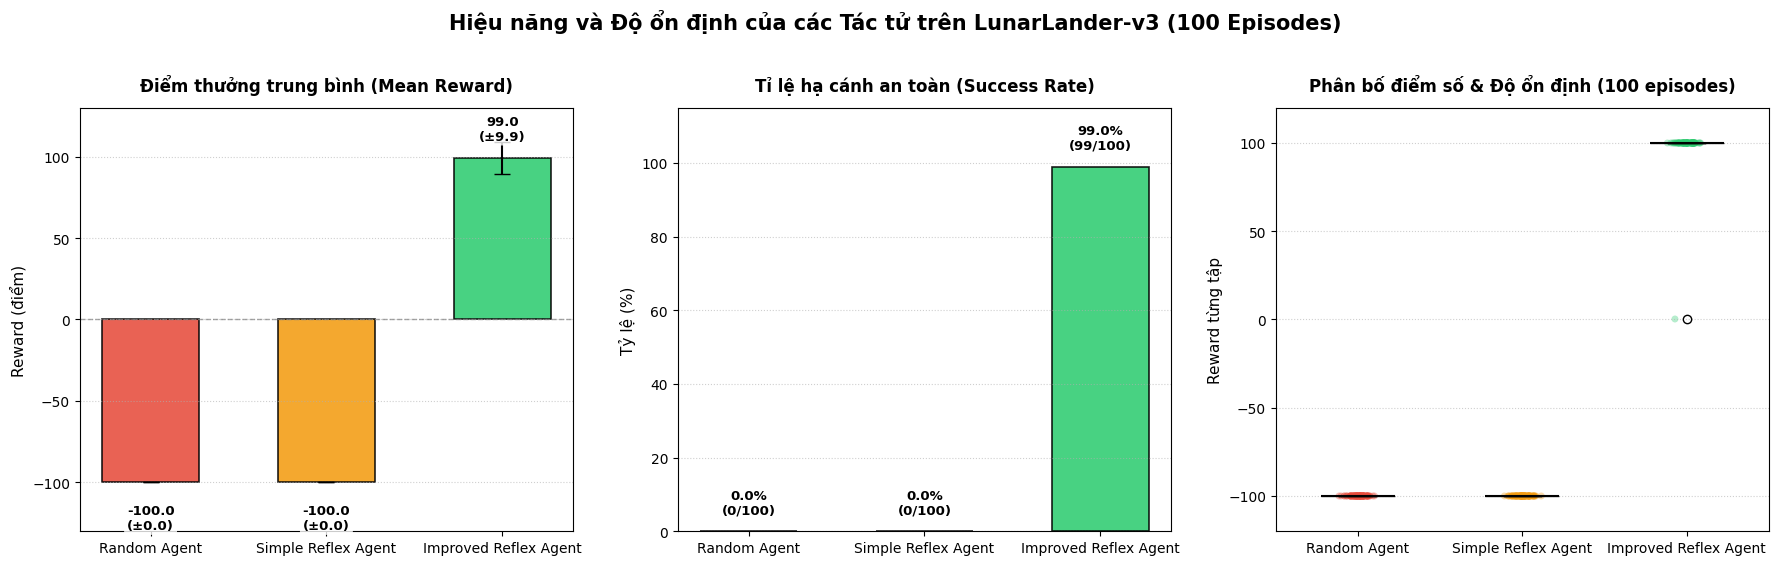

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Tính toán các chỉ số thống kê
means = [np.mean(r) for r in all_rewards]
stds = [np.std(r) for r in all_rewards]
success_rates = [np.mean(np.array(r) == 100) * 100 for r in all_rewards]

# 2. Thiết lập Dashboard trực quan 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=100)
fig.suptitle('Hiệu năng và Độ ổn định của các Tác tử trên LunarLander-v3 (100 Episodes)', fontsize=15, fontweight='bold', y=1.02)

colors = ['#e74c3c', '#f39c12', '#2ecc71']
x_pos = np.arange(len(agents))

# --- Biểu đồ 1: Mean Reward kèm Std Dev ---
bars1 = axes[0].bar(x_pos, means, yerr=stds, capsize=6, color=colors, alpha=0.88, edgecolor='black', linewidth=1.2, width=0.55)
axes[0].set_title('Điểm thưởng trung bình (Mean Reward)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Reward (điểm)', fontsize=11)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(agents, fontsize=10, fontweight='medium')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)
axes[0].set_ylim(-130, 130)

for bar, mean, std in zip(bars1, means, stds):
    y_pos = mean - 22 if mean < 0 else mean + 18
    axes[0].text(bar.get_x() + bar.get_width() / 2, y_pos, f'{mean:.1f}\n(±{std:.1f})',
                 ha='center', va='center', fontsize=9.5, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# --- Biểu đồ 2: Tỉ lệ hạ cánh thành công ---
bars2 = axes[1].bar(x_pos, success_rates, color=colors, alpha=0.88, edgecolor='black', linewidth=1.2, width=0.55)
axes[1].set_title('Tỉ lệ hạ cánh an toàn (Success Rate)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Tỷ lệ (%)', fontsize=11)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(agents, fontsize=10, fontweight='medium')
axes[1].set_ylim(0, 115)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

for bar, rate in zip(bars2, success_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, rate + 4, f'{rate:.1f}%\n({int(rate)}/100)',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# --- Biểu đồ 3: Phân bố điểm số & Độ ổn định qua 100 tập ---
box = axes[2].boxplot(all_rewards, tick_labels=agents, patch_artist=True, widths=0.45,
                      medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

for i, r in enumerate(all_rewards):
    jitter = np.random.normal(0, 0.04, size=len(r))
    axes[2].scatter(np.full_like(r, i + 1) + jitter, r, alpha=0.35, color=colors[i], edgecolors='none', s=25)

axes[2].set_title('Phân bố điểm số & Độ ổn định (100 episodes)', fontsize=12, fontweight='bold', pad=12)
axes[2].set_ylabel('Reward từng tập', fontsize=11)
axes[2].set_ylim(-120, 120)
axes[2].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
